In [ ]:
from datasets import load_dataset

import numpy as np
import torch
import matplotlib.pyplot as plt
from configurations.plot_config import set_font_sizes, apply_general_styles, create_fig, FONTSIZES
from configurations.data_config import make_params_dict , load_data, save_fig

from attention_nn.dataset import get_all_sentences, build_tokenizer, get_dataloader
from attention_nn.model import create_model

apply_general_styles()

/u/c/cerazova/miniconda3/envs/transf/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Test scales

In [2]:
# Define configuration

config = {
    'd_model': 10000,
    'dataset_size': 100,
    'train_fraction': 0.9,
    'batch_size': 1,
    'seq_len': 124,
    'dropout': 0.0,
    'rank': 102,
    'num_epochs': 5,
    'lr': 1.0,
    'datasource': 'roneneldan/TinyStories',
    'freeze_embeddings': False,
    'freeze_attention': False,
    'random_positional_encoding': False,
    'skip_residual': False,
    'amplitude': 1.0,
    'sigma': 1,
}

config['amplitude'] = 0.0#config['amplitude']/np.sqrt(config['d_model'])  # Scale amplitude with sqrt(d_model)

In [3]:
# Prepare data loaders and tokenizer
print('Preparing data loaders...')
train_dataloader, val_dataloader , tokenizer = get_dataloader(config)
config['vocab_size'] = tokenizer.get_vocab_size()
print(f'Vocabulary size = {config["vocab_size"]}. Maximum entropy per token = {np.log(config["vocab_size"]):.4f} nats.')
pad_id = tokenizer.token_to_id("[PAD]")

# Set device and build model
model , device = create_model(config)
print(f'Model built on device: {device}')

Preparing data loaders...


Min sequence length = 94
Max sequence length = 267
Vocabulary size = 1019. Maximum entropy per token = 6.9266 nats.
Model built on device: cuda


In [4]:
for batch in train_dataloader:
    input = batch['input'].to(device) # (batch_size, seq_len)
    label = batch['label'].to(device) # (batch_size, seq_len)
    mask = batch['attention_mask'].to(device) # (batch_size, seq_len, seq_len)

    e = model.input_embeddings(input)  # (batch, seq_len, d_model)
    xp = model.positional_encoding(e)  # (batch, seq_len, d_model)
    proj_left = model.attention_layer.Wq(xp)   # (batch, seq_len, rank) - cheaper!
    proj_right = model.attention_layer.Wk(xp)  # (batch, seq_len, rank)
    dot  = proj_left @ proj_right.transpose(-2, -1)/  (np.sqrt(model.rank))
    A =  torch.softmax(dot.masked_fill(mask==0,-1e9), dim=-1)
    # A = model.attention_layer.attention_probabilities(xp,mask)
    xa = A @ xp
    xo = xa + xp

    break


np.float32(0.023341483)

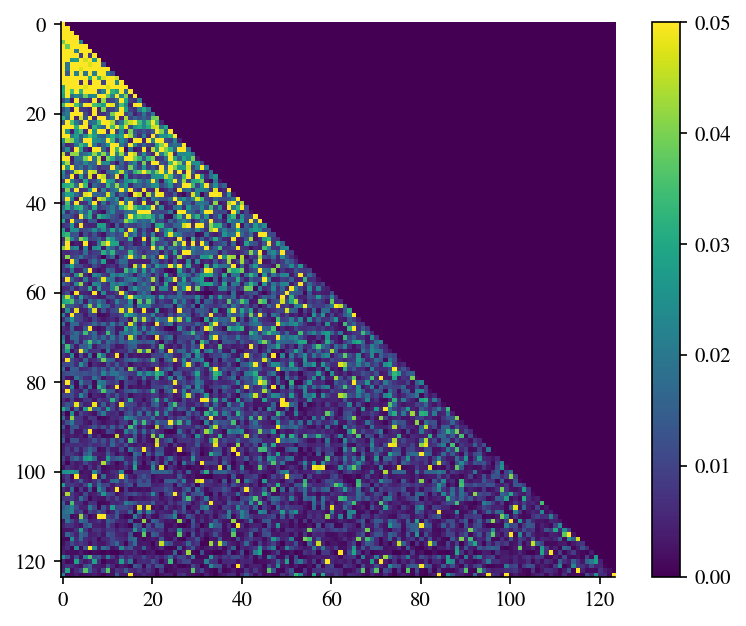

In [7]:
a = (A[0]).cpu().detach().numpy() 
plt.imshow(a,vmax=0.05)
plt.colorbar()

a.std()

# Plots measurements

In [16]:
d = 512
dataset_size = 10000
L = 128
batch_size = 64
lr = 0.05
rank = None
fr_emb = False
fr_att = False
beta=1.0
sigma=0.1

skip_residual = False
type_enc = 'wave'


# fix_names = ['rank','d_model','seq_len','dataset_size','random_positional_encoding'][:-1]
# var_names = ['batch_size','lr','freeze_embeddings','freeze_attention','skip_residual']
fix_names = ['rank','d','L','dataset_size','skip_residual']
var_names = ['batch_size','lr','fr_emb','fr_att','type_enc','beta','sigma']
params = make_params_dict(fix_names , var_names)


summary = load_data('summary',experiment_name='tests_evolution', params=params)

for key in summary.keys():
    if key != 'embedd_top_tokens':
        print(f'{key}: {summary[key].shape}')

        

File summary_batch_size64_beta1_fr_attFalse_fr_embFalse_lr0.05_sigma0.1_type_encwave.pkl loaded with pickle.load from /u/c/cerazova/Transformers/data/tests_evolution/L128_d512_dataset_size10000_rankNone_skip_residualFalse
train_loss: (101,)
val_loss: (101,)
entropy: (101, 5)
part_ratio: (101, 5)
sequence_fractions: (5,)
evaluation_steps: (101,)
vocab_size: ()
embedd_eigvals: (101, 512)
W_eigvals: (101, 512)
attention_patterns: (101, 128, 128)
norm_W: (101,)
x: (101, 128, 512)
e: (101, 128, 512)
grad_embedding: (101,)
grad_W: (101,)
grad_projection: (101,)


In [17]:
step = summary['evaluation_steps']
vocab_size = int(summary['vocab_size'])
sequence_fractions = summary['sequence_fractions']
embedd_top_tokens = summary['embedd_top_tokens']
print(f'Seq fractions: {sequence_fractions}')
k = 4
print(f'Tokens aligned with {k}-th top eigvector of embedding covariance matrix:')
for i , toks in enumerate(embedd_top_tokens[::3]):
    print(f'Step {step[::3][i]}: {toks[k]}')
# print(f'Embedd top tokens shape: {embedd_top_tokens}')


Seq fractions: [0.2 0.4 0.6 0.8 1. ]
Tokens aligned with 4-th top eigvector of embedding covariance matrix:
Step 0: ['Do', 'available', 'farm', 'Riding', 'crumb', 'Isn', 'astounded', 'patched', 'drum', 'Bruce', 'soaked', 'forest', 'should', 'herself', 'spicy', 'practising', 'burying', 'flavors', 'knew', 'Tonya', 'Jonny', 'sweaters', 'rings', 'lions', 'Someday', 'Andi', 'sailboat', 'gain', 'stomach', 'Jose']
Step 63: ['to', 'And', 'we', 'Together', 'After', 'Can', 'Once', 'take', 'began', 'chimney', 'gone', 'tried', 'relief', 'present', 'want', 'dinner', '.', 'giggled', 'Ah', 'lived', 'monkey', 'whip', 'coming', 'Sandy', 'needle', 'end', 'Henry', 'loved', 'At', 'From']
Step 126: ['to', 'want', '.', 'Every', 'Suddenly', 'His', 'wanted', 'take', 'After', 'go', 'When', 'decided', 'One', 'So', 'But', 'Her', 'began', 'At', 'Then', 'make', 'All', 'As', 'started', 'be', 'year', 'day', 't', 'keep', 'get', 'Finally']
Step 189: ['One', 'want', 'Every', '.', 'day', 'His', 'But', 'Her', 'When', 'to

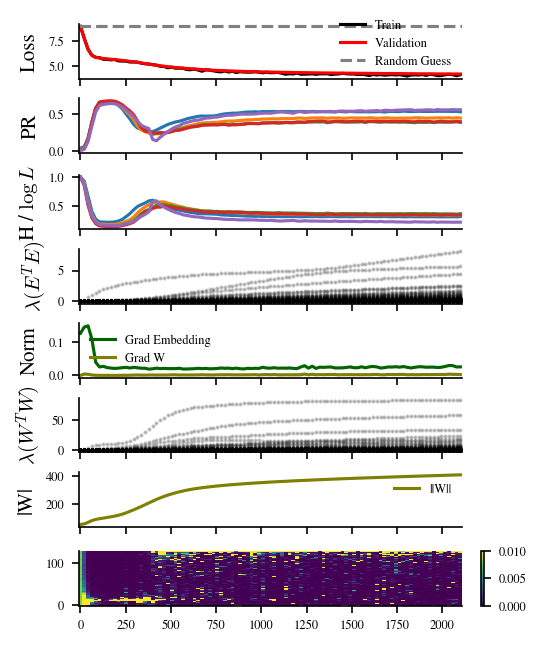

In [18]:


set_font_sizes(conf='tight')
i_seq_frac = -1  # index of sequence fraction to plot
fig , axes = create_fig(nrows=8,h=1.2)

ax = axes[0]
ax.plot(step,summary['train_loss'], label='Train', color='k')
ax.plot(step,summary['val_loss'], label='Validation', color='r')
ax.axhline(np.log(vocab_size), color='gray', linestyle='--', label='Random Guess')
ax.set_ylabel('Loss')
ax.legend(frameon=False)


ax = axes[1]
ax.plot(step, summary['part_ratio'], label='Validation')
ax.set_ylabel('PR')
# ax.legend(frameon=False)


ax = axes[2]
ax.plot(step, summary['entropy'], label='Validation')
ax.set_ylabel(r'H / $\log L$')
# ax.legend(frameon=False)    



ax = axes[3]
for i , t in enumerate(step):
    ax.scatter([t]*d,summary['embedd_eigvals'][i],s=1,alpha=0.2,color='k')

ax.set_ylabel(r'$\lambda(E^T E)$')
# ax.set_yscale('log')

ax = axes[4]
ax.plot(step, summary['grad_embedding'],label='Grad Embedding', color='darkgreen')
# ax.plot(step,summary['grad_positional_encoding'],label='Grad Pos Enc', color='darkred')
if rank is not None:
    print(rank)
    ax.plot(step, summary['grad_Wq'],label='Grad Wq', color='olive')
    ax.plot(step, summary['grad_Wk'],label='Grad Wk', color='darkblue')
else:
    ax.plot(step,summary['grad_W'],label='Grad W', color='olive')
ax.set_ylabel('Norm')
ax.legend(frameon=False)
# ax.set_yscale('log')

ax = axes[5]
m = rank if rank is not None else d
for i , t in enumerate(step):
    ax.scatter([t]*m,summary['W_eigvals'][i],s=1,alpha=0.2,color='k')
ax.set_ylabel(r'$\lambda(W^T W)$')
# ax.set_yscale('log')

ax = axes[6]
ax.plot(step, summary['norm_W'] , label='||W||', color='olive')
ax.set_ylabel('|W|')
ax.legend(frameon=False)


ax = axes[7]

attention_patterns = summary['attention_patterns']  # (num_steps, L, L)
i_seq = L//1 - 1

# ax.set_xlim(0,200)

mesh = ax.pcolormesh(step, np.arange(L), attention_patterns[:, i_seq].T, shading='auto',vmax=0.01)
plt.colorbar(mesh, ax=ax)

[ 0 13 26 39 52 65 78 91]
0 0
1 13
2 26
3 39
4 52
5 65
6 78
7 91
8


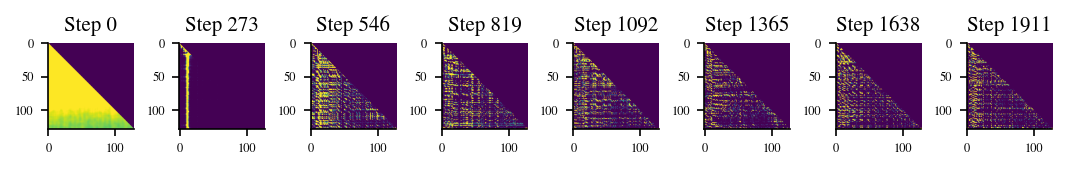

In [19]:

fig , axes = create_fig(ncols=8,w=2)

idx = np.arange(0,len(step),max(1,len(step)//8 +1))
print(idx)
for i , t in enumerate(idx):
    ax = axes[i]
    print(i,t)
    ax.imshow(attention_patterns[t],vmax=0.01)
    ax.set_title(f'Step {step[t]}')
print(len(idx))

# Polished Plot

In [ ]:
step_scalars = summary['evaluation_steps']
vocab_size = int(summary['vocab_size'])
sequence_fractions = summary['sequence_fractions']
i_seq_frac = 3
set_font_sizes(conf='tight')

fig , axes = create_fig(nrows=5,h=1)

ax = axes[0]
ax.plot(step,summary['val_loss'], label='Validation', color='olive',ls='-')
ax.plot(step,summary['train_loss'], label='Train', color='k',ls='--',lw=1)
ax.axhline(np.log(vocab_size), color='gray', linestyle='--', label=r'$\log V$')
ax.axhline(5.9066, color='b', linestyle='--', label=r'$H[P_{uni}]$')
ax.set_ylabel('Loss')
ax.legend(frameon=False,ncols=2)

ax = axes[1]
ax.plot(step, summary['entropy'][:,i_seq_frac], label=r'$H/\log L$', color='peru',ls='-')
ax.plot(step, summary['part_ratio'][:,i_seq_frac], label='PR', color='k',ls='-')
ax.set_ylabel('Sparcity')
ax.legend(frameon=False,ncols=2,loc='upper right')
ax.text(x=0.1, y=0.6, 
        s=fr'At ${ 100* sequence_fractions[i_seq_frac]:.0f} \% L$',
        transform=ax.transAxes,
        fontsize=FONTSIZES['xs'])

ax = axes[2]
for i , t in enumerate(step):
    ax.scatter([t]*d,summary['embedd_eigvals'][i],s=1,alpha=0.2,color='k')
ax.set_ylabel(r'$\lambda(E^T E)$',size=FONTSIZES['s'])

ax = axes[3]
for i , t in enumerate(step):
    ax.scatter([t]*d,summary['W_eigvals'][i]/d,s=1,alpha=0.2,color='k')
ax.set_ylabel(r'$\lambda(W^T W)$',size=FONTSIZES['s'])


ax = axes[4]

attention_patterns = summary['attention_patterns']  # (num_steps, L, L)
i_seq = int(sequence_fractions[i_seq_frac]*L) - 1
mesh = ax.pcolormesh(step, np.arange(L)/L, attention_patterns[:, i_seq].T,cmap='YlGnBu_r',vmax=0.01)
plt.colorbar(mesh, ax=ax)
ax.set_ylim(0,1)
ax.set_ylabel(r'$\mu / L$')
ax.set_xlabel('Training Step')

# ax.set_xscale('log')
# ax.set_xlim(0,100)


names = ['d','L','lr','fr_emb','fr_att','skip_residual','type_enc','beta']
params = make_params_dict(names)
# save_fig(fig,'measures',params=params)

NameError: name 'summary' is not defined

# plots with embeddings

In [6]:
d_model = 1024
dataset_size = 10000
seq_len = 256
batch_size = 64
lr = 0.001
rank = None
freeze_embeddings = False
freeze_attention = True
skip_residual = False
random_positional_encoding = False


fix_names = ['rank','d_model','seq_len','dataset_size','random_positional_encoding'][:-1]
var_names = ['batch_size','lr','freeze_embeddings','freeze_attention','skip_residual']
params = make_params_dict(fix_names , var_names)


summary = load_data('summary',experiment_name='new_measurements', params=params)
summary_embeddings = load_data('summary_embeddings',experiment_name='new_measurements', params=params)
for key in summary.keys():
    if key != 'embedd_top_tokens':
        print(f'{key}: {summary[key].shape}')

for key in summary_embeddings.keys():
    if key != 'tokens':
        summary_embeddings[key] = np.array(summary_embeddings[key])
        print(f'{key}, shape: {summary_embeddings[key].shape}')

print(summary_embeddings['tokens'][:10])  
print(summary_embeddings['embeddings_steps']) 

File summary_batch_size64_freeze_attentionTrue_freeze_embeddingsFalse_lr0.001_skip_residualFalse.pkl loaded with pickle.load from /u/c/cerazova/Transformers/data/new_measurements/d_model1024_dataset_size10000_rankNone_seq_len256
File summary_embeddings_batch_size64_freeze_attentionTrue_freeze_embeddingsFalse_lr0.001_skip_residualFalse.pkl loaded with pickle.load from /u/c/cerazova/Transformers/data/new_measurements/d_model1024_dataset_size10000_rankNone_seq_len256
train_loss: (212,)
val_loss: (212,)
entropy: (212, 5)
part_ratio: (212, 5)
sequence_fractions: (5,)
evaluation_steps: (212,)
vocab_size: ()
embedd_eigvals: (212, 1024)
W_eigvals: (212, 1024)
attention_patterns: (212, 256, 256)
norm_W: (212,)
positional_encodings: (212, 256, 1024)
grad_embedding: (212,)
grad_W: (212,)
embeddings, shape: (11, 8043, 1024)
embeddings_steps, shape: (11,)
['[UNK]', '[PAD]', '[SOS]', '[EOS]', '.', 'and', ',', 'the', 'to', 'a']
[   0  211  422  633  844 1055 1266 1477 1688 1899 2110]


In [118]:
step = summary['evaluation_steps']
vocab_size = int(summary['vocab_size'])
sequence_fractions = summary['sequence_fractions']
embedd_top_tokens = summary['embedd_top_tokens']
print(f'Seq fractions: {sequence_fractions}')
k = 7
print(f'Tokens aligned with {k}-th top eigvector of embedding covariance matrix:')
for i , toks in enumerate(embedd_top_tokens[::3]):
    print(f'Step {step[::3][i]}: {toks[k]}')
# print(f'Embedd top tokens shape: {embedd_top_tokens}')


Seq fractions: [0.2 0.4 0.6 0.8 1. ]
Tokens aligned with 7-th top eigvector of embedding covariance matrix:
Step 0: ['bags', 'room', 'tracks', 'humming', 'œSee', 'serious', 'swordfish', 'mop', 'Catch', 'group', 'ashamed', 'breeze', 'Tracey', 'replace', 'fidget', 'pause', 'seriously', 'catches', 'weighing', 'œTime', 'chalk', "'.", 'Plus', 'chews', 'uniform', 'leads', 'Roy', 'pays', 'Abigail', 'collected']
Step 30: ['hey', 'swung', 'hold', 'tube', 'given', 'cowboys', 'encouragement', 'œExcuse', 'shoreline', 'caution', 'skills', 'selfishness', 'cool', 'sticker', 'keys', 'evening', 'continue', 'whatever', 'long', 'shaking', 'pretending', 'Shadow', 'scanning', 'salty', 'surprisingly', 'sense', 'Tia', 'entering', 'Who', 'Sun']
Step 60: ['cool', 'steam', 'nice', 'Soon', 'nutty', 'greet', 'magic', 'was', 'polite', 'sky', 'worked', 'films', 'chimed', 'long', 'deserved', 'Surprise', 'came', 'Luther', 'Auntie', 'Judy', 'saving', 'Sammy', 'pout', 'daydreaming', 'given', 'rake', 'bitten', 'Roy', 'm

In [119]:
emb_steps = summary_embeddings['embeddings_steps']
steps_print = emb_steps[::2]
n_steps = len(steps_print)

step = summary['evaluation_steps']
embedd_top_tokens = summary['embedd_top_tokens']

n_vectors = 5
n_tokens = 6
centers = '|c'*n_steps + '|'
print("\\begin{tabular}{|c|"+'|c'*n_steps+'|}')
print("\\hline")
print(" \\parbox[c]{5em}{ } & " + " & ".join([f'\\parbox[c]{{8em}}{{Step {s}}}' for s in steps_print]) + " \\\\")
print("\\hline \\hline")
for k in range(n_vectors):
    row = [f'V${k+1}$']
    for s in steps_print:
        idx = np.argmin(np.abs(step - s))
        toks = embedd_top_tokens[idx][k][:n_tokens]
        toks_str = ', '.join([str(t) for t in toks])
        new_toks_str = f'\\parbox[c]{{7em}}{{{toks_str}}}'
        # print(new_toks_str)
        row.append(new_toks_str)
    print(" & ".join(row) + " \\\\")
    print("\\hline")

print("\\end{tabular}")

\begin{tabular}{|c||c|c|c|c|c|c|}
\hline
 \parbox[c]{5em}{ } & \parbox[c]{8em}{Step 0} & \parbox[c]{8em}{Step 422} & \parbox[c]{8em}{Step 844} & \parbox[c]{8em}{Step 1266} & \parbox[c]{8em}{Step 1688} & \parbox[c]{8em}{Step 2110} \\
\hline \hline
V$1$ & \parbox[c]{7em}{Down, curled, staying, mayor, earlier, Whoever} & \parbox[c]{7em}{., ,, to, said, He, She} & \parbox[c]{7em}{went, to, ran, wanted, back, decided} & \parbox[c]{7em}{ran, put, back, over, them, off} & \parbox[c]{7em}{don, Why, Don, front, into, Thank} & \parbox[c]{7em}{front, don, Why, middle, Don, into} \\
\hline
V$2$ & \parbox[c]{7em}{freely, sun, fold, court, œTime, heard} & \parbox[c]{7em}{I, ', don, ", Let, Thank} & \parbox[c]{7em}{Can, Thank, Yes, ", I, What} & \parbox[c]{7em}{should, we, want, could, can, don} & \parbox[c]{7em}{decided, give, could, listen, want, to} & \parbox[c]{7em}{give, keep, to, decided, promised, talk} \\
\hline
V$3$ & \parbox[c]{7em}{Fido, pull, landscape, opens, mouth, munched} & \parbox[c]

(6, 8043, 1024)
(6, 8043, 2)


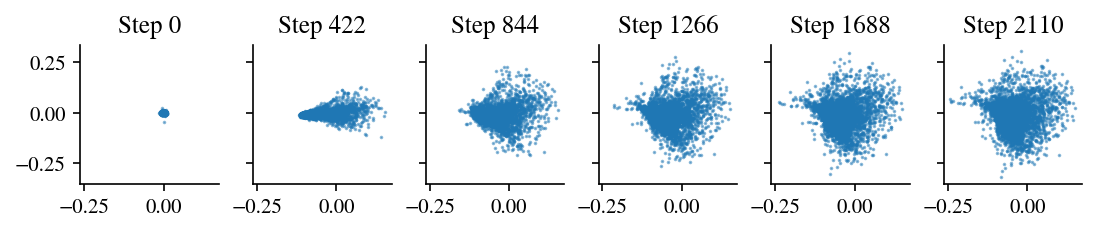

In [120]:
emb_steps = summary_embeddings['embeddings_steps']
embeddings = summary_embeddings['embeddings']  # (n_steps, vocab_size, d_model)
tokens = summary_embeddings['tokens']
steps_print = emb_steps[::2]
embeddings_print = embeddings[::2]
n_steps = len(steps_print)
vocab_size = int(summary['vocab_size'])
print(embeddings_print.shape)

E_last = embeddings_print[-1]  # (vocab_size, d_model)
C = E_last.T @ E_last / vocab_size  # (d_model, d_model)
# Project onto top 2 eigenvectors
eigval, eigvec = np.linalg.eigh(C)
idx = np.argsort(eigval)[::-1]
eigval = eigval[idx]
eigvec = eigvec[:,idx]  
E_projected = embeddings_print @ eigvec[:,:2]  # (n_steps, vocab_size, 2)
print(E_projected.shape)

fig , axes = create_fig(ncols=n_steps,size='double',h=0.2,sharey=True)

for i in range(n_steps):
    ax = axes[i]
    ax.scatter(E_projected[i,:,0], E_projected[i,:,1], s=0.5, alpha=0.5)
    ax.set_title(f'Step {steps_print[i]}')
    # Annotate some tokens
    # for j in range(10):
    #     token_id = tokens[j]
    #     x = E_projected[i,token_id,0]
    #     y = E_projected[i,token_id,1]
    #     ax.annotate(str(token_id), (x,y), fontsize=6)


# save_fig(fig,'embedding_evolution_2D_random_encoding')



# Data statistics

In [51]:
# Define configuration

config = {
    'dataset_size': 10000,
    'train_fraction': 0.9,
    'batch_size': 1,
    'L': 128,
    'datasource': 'roneneldan/TinyStories',
}

# Prepare data loaders and tokenizer
print('Preparing data loaders...')
train_dataloader, val_dataloader , tokenizer = get_dataloader(config)
vocab_size = tokenizer.get_vocab_size()
print(f'Vocabulary size = {vocab_size}. Maximum entropy per token = {np.log(vocab_size):.4f} nats.')
pad_id = tokenizer.token_to_id("[PAD]")

Preparing data loaders...


Min sequence length = 53
Max sequence length = 1040
Vocabulary size = 8043. Maximum entropy per token = 8.9926 nats.


In [121]:
# Measure token frequency in all dataset for each position in sequence
token_counts = np.zeros((config['L'], vocab_size))

for batch in train_dataloader:
    input = batch['input'][0].numpy() # (seq_len,)
    token_counts[np.arange(config['L']), input] += 1
for batch in val_dataloader:
    input = batch['input'][0].numpy() # (seq_len,)
    token_counts[np.arange(config['L']), input] += 1

# Eliminate data from padding tokens
token_counts[:, pad_id] = 0
total_counts = token_counts.sum(axis=0)  # (vocab_size,)
print(total_counts[pad_id])  # Should be zero
sorted_tokens = np.argsort(-total_counts)  # Indices of tokens sorted by frequency descending
token_counts = token_counts[:, sorted_tokens]  # Sort token counts accordingly
total_counts = total_counts[sorted_tokens]
print(total_counts[sorted_tokens==pad_id])  # Should be zero


0.0
[0.]


In [130]:
np.where(sorted_tokens == pad_id)[0][0]

np.int64(8040)

In [122]:
sorted_tokens[:10]

array([ 4,  6,  7,  5,  9,  8, 10, 11, 13, 12])

In [125]:
tokenizer.id_to_token(7)

'the'

In [119]:
for i in sorted_token_indices[-10:]:
    print(f'Token id {i}: count = {total_counts[i]}, token = {tokenizer.id_to_token(i)}')

Token id 6677: count = 2.0, token = painful
Token id 6665: count = 2.0, token = nightstand
Token id 6683: count = 1.0, token = peopleâ
Token id 6687: count = 1.0, token = persistence
Token id 8029: count = 0.0, token = œSometimes
Token id 7991: count = 0.0, token = whispers
Token id 7969: count = 0.0, token = waists
Token id 1: count = 53017.0, token = [PAD]
Token id 7984: count = 0.0, token = whine
Token id 7981: count = 0.0, token = weightless


idx=0 ['Once', 'One', 'Lily', 'Tom', 'Anna', 'Sara', 'John', 'The', 'Ben', 'Tim', 'Sam', 'Lila']
idx=1 ['upon', 'and', 'there', 'was', 'day', 'liked', ',', 'had', 'loved', 'sun', 'likes', 'little']
idx=2 ['a', 'was', ',', 'Ben', 'to', 'Lily', 'Tom', 'Mia', 'there', 'Sam', 'his', 'her']
idx=3 ['girl', '.', 'boy', 'named', ',', 'play', 'who', 'to', 'the', 'They', 'called', 'a']
idx=4 ['.', 'the', ',', 'to', 'and', 'a', 'was', 'it', '"', 'said', "'", 'he']
idx=5 ['.', 'the', ',', 'and', 'to', 'was', 'it', 'a', "'", 'her', 'The', 'said']
idx=6 ['.', ',', 'the', 'and', 'a', 'to', 'was', 'it', 'her', '"', 'She', 'He']


Text(0.025, 0.75, 'Frequent\nTokens')

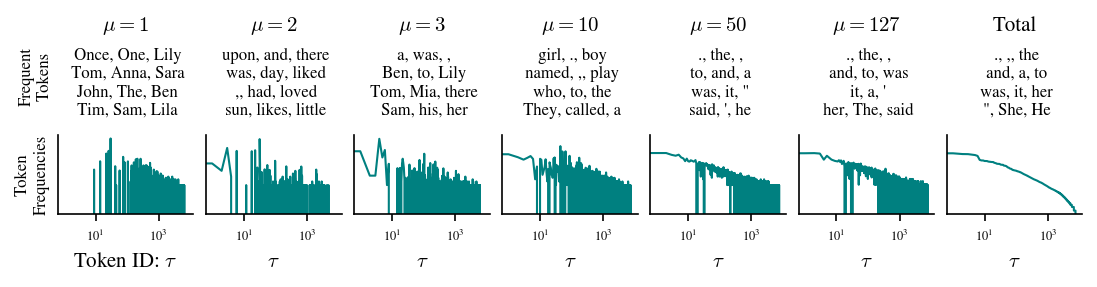

In [64]:
# Setup and variables for plotting
L = config['L']
window = 1

k = 12
# pos_to_plot = np.linspace(1,L-1-window,m).astype(int)
pos_to_plot = [1,2,3,10,50,L-1]
m = len(pos_to_plot)

fig , axes = create_fig(ncols=m+1,nrows=2,size='double',h=0.25,sharey=True)

for i in range(m+1):
    if i < m:
        # print(pos_to_plot[i],pos_to_plot[i]+window)
        # freqs = token_counts[pos_to_plot[i]:pos_to_plot[i]+window].sum(axis=0)
        freqs = token_counts[pos_to_plot[i]]
    else:
        freqs = total_counts
    freqs /= freqs.sum()
    # Top k tokens ids
    top_k_tokes_id = np.argsort(-freqs)[:k]
    top_k_tokens = [tokenizer.id_to_token(sorted_token_indices[j]) for j in top_k_tokes_id]
    print(f'idx={i}',top_k_tokens)
    ax = axes[0,i]
    ax.set_axis_off()
    
        
    # if i == 0: ax.set_ylabel('Frequent\nTokens',size=FONTSIZES['s'])
    text = '\n'.join([f' {top_k_tokens[j]}, {top_k_tokens[j+1]}, {top_k_tokens[j+2]}' for j in range(0,k-2,3)]) 
    ax.text(0.5, 0.5, text, fontsize=FONTSIZES['s'], va='center', ha='center', transform=ax.transAxes)
    ax.set_title(rf'$\mu={pos_to_plot[i]}$' if i < m else 'Total')


    # Plot token frequency distribution
    ax = axes[1,i]
    if i == 0: ax.set_ylabel('Token\nFrequencies',size=FONTSIZES['s'])
    
    ax.plot(freqs,color='teal',lw=1.)
    ax.set_yscale('log')
    ax.set_xscale('log')
    ax.set_xlabel(r'Token ID: $\tau$' if i == 0 else r'$\tau$')

    ax.set_yticks([])
    
fig.text(0.025, 0.75, 'Frequent\nTokens', fontsize=FONTSIZES['s'], va='center', ha='center', transform=fig.transFigure,rotation=90)
    

# New full plots

In [146]:
d = 512
dataset_size = 10000
L = 128
batch_size = 64
lr = 0.05
rank = None
fr_emb = False
fr_att = False
skip_residual = False
beta=1.0
sigma=0.1
type_enc = 'wave'


fix_names = ['rank','d','L','dataset_size','skip_residual']
var_names = ['batch_size','lr','fr_emb','fr_att','type_enc','beta','sigma']
params = make_params_dict(fix_names , var_names)


summary_scalar = load_data('summary',experiment_name='evolution_scalar', params=params)
summary_matrices = load_data('summary',experiment_name='evolution_matrices', params=params)


print('In scalar summary:')
for key in summary_scalar.keys():
    if key != 'embedd_top_tokens':
        print(f'{key}: {summary_scalar[key].shape}')

print('\nIn matrices summary:')
for key in summary_matrices.keys():
    if key != 'tokens' and key != 'tokens_attended' and key != 'tokens_next':
        print(f'{key}: {summary_matrices[key].shape}')
        

File summary_batch_size64_beta1_fr_attFalse_fr_embFalse_lr0.05_sigma0.1_type_encwave.pkl loaded with pickle.load from /u/c/cerazova/Transformers/data/evolution_scalar/L128_d512_dataset_size10000_rankNone_skip_residualFalse
File summary_batch_size64_beta1_fr_attFalse_fr_embFalse_lr0.05_sigma0.1_type_encwave.pkl loaded with pickle.load from /u/c/cerazova/Transformers/data/evolution_matrices/L128_d512_dataset_size10000_rankNone_skip_residualFalse
In scalar summary:
evaluation_steps: (21,)
train_loss: (21,)
val_loss: (21,)
entropy: (21, 5)
part_ratio: (21, 5)
pos_attended: (21, 5)
att_in_fractions: (21, 5, 128)
embedd_eigvals: (21, 512)
embedd_mean: (21,)
embedd_std: (21,)
W_eigvals: (21, 512)
W_mean: (21,)
W_std: (21,)
sequence_fractions: (5,)
vocab_size: ()
grad_embedding: (21,)
grad_W: (21,)
grad_projection: (21,)

In matrices summary:
matrix_steps: (8,)
A: (8, 128, 128)
x: (8, 128, 512)
e: (8, 128, 512)
embeddings: (8, 8043, 512)
embedd_grad_norms: (8, 8043)
W: (8, 512, 512)


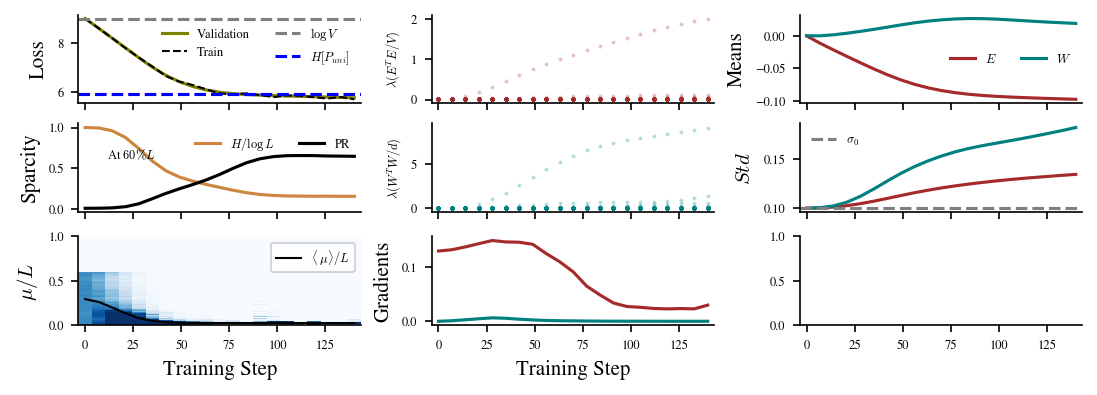

In [147]:
# Setup and variables
step_scalar = summary_scalar['evaluation_steps']
vocab_size = int(summary_scalar['vocab_size'])
sequence_fractions = summary_scalar['sequence_fractions']
i_seq_frac = 2
set_font_sizes(conf='tight')
color_E = 'brown'
color_W = 'teal'

# Create figure
fig , axes = create_fig(nrows=3,ncols=3,size='double',h=0.35)



# Loss
ax = axes[0,0]
ax.plot(step_scalar,summary_scalar['val_loss'], label='Validation', color='olive',ls='-')
ax.plot(step_scalar,summary_scalar['train_loss'], label='Train', color='k',ls='--',lw=1)
ax.axhline(np.log(vocab_size), color='gray', linestyle='--', label=r'$\log V$')
ax.axhline(5.9066, color='b', linestyle='--', label=r'$H[P_{uni}]$')
ax.set_ylabel('Loss')
ax.legend(frameon=False,ncols=2)

# Sparcity Measures
ax = axes[1,0]
ax.plot(step_scalar, summary_scalar['entropy'][:,i_seq_frac], label=r'$H/\log L$', color='peru',ls='-')
ax.plot(step_scalar, summary_scalar['part_ratio'][:,i_seq_frac], label='PR', color='k',ls='-')
ax.set_ylabel('Sparcity')
ax.legend(frameon=False,ncols=2,loc='upper right')
ax.text(x=0.1, y=0.6, 
        s=fr'At ${ 100* sequence_fractions[i_seq_frac]:.0f} \% L$',
        transform=ax.transAxes,
        fontsize=FONTSIZES['xs'])


# Attention Pattern
ax = axes[2,0]

attention_patterns = summary_scalar['att_in_fractions']  # (num_step_scalars, len(seq_fract), L)
mesh = ax.pcolormesh(step_scalar, np.arange(L)/L, attention_patterns[:, i_seq_frac].T,cmap='Blues',vmax=0.02)
ax.plot(step_scalar,sequence_fractions[i_seq_frac]*summary_scalar['pos_attended'][:,i_seq_frac], 
        label=r'$\langle \;\mu \rangle / L$', color='k',ls='-',lw=1)

# plt.colorbar(mesh, ax=ax)
ax.legend(frameon=True,ncols=2)
ax.set_ylim(0,1)
ax.set_ylabel(r'$\mu / L$')
ax.set_xlabel('Training Step')


# Embedding Eigenvalues
ax = axes[0,1]
for i , t in enumerate(step_scalar):
    ax.scatter([t]*d,summary_scalar['embedd_eigvals'][i],s=1,alpha=0.2,color=color_E)
ax.set_ylabel(r'$\lambda(E^T E / V)$',size=FONTSIZES['xs'])

# Weight Eigenvalues
ax = axes[1,1]
for i , t in enumerate(step_scalar):
    ax.scatter([t]*d,summary_scalar['W_eigvals'][i],s=1,alpha=0.2,color=color_W)
ax.set_ylabel(r'$\lambda(W^T W / d)$',size=FONTSIZES['xs'])

# Gradients
ax = axes[2,1]
ax.plot(step_scalar,summary_scalar['grad_embedding'], label=r'$\nabla E$', color=color_E,ls='-')
ax.plot(step_scalar,summary_scalar['grad_W'], label=r'$\nabla W$', color=color_W,ls='-')
ax.set_ylabel('Gradients')
# ax.legend(frameon=False,ncols=2)
ax.set_xlabel('Training Step')

# Means
ax = axes[0,2]
ax.plot(step_scalar,summary_scalar['embedd_mean'], label=r'$E$', color=color_E,ls='-')
ax.plot(step_scalar,summary_scalar['W_mean'], label=r'$W$', color=color_W,ls='-')
ax.set_ylabel('Means')
ax.legend(frameon=False,ncols=2)

# Stddevs
ax = axes[1,2]
ax.plot(step_scalar,summary_scalar['embedd_std'], color=color_E,ls='-')
ax.plot(step_scalar,summary_scalar['W_std'], color=color_W,ls='-')
ax.axhline(sigma,color='gray',ls='--',label=r'$\sigma_0$')
ax.set_ylabel(r'$Std$')
ax.legend(frameon=False,ncols=1)
# ax.set_xlim(0,100)
# ax.set_ylim(0,0.5)


# names = ['d','L','lr','fr_emb','fr_att','skip_residual','type_enc','beta']
# params = make_params_dict(names)
# save_fig(fig,'measures',params=params)

In [132]:
# embedd_grad_norms: (6, 8043)
summary_matrices['embedd_grad_norms'][:,pad_id+1]

array([0.00129647, 0.00057536, 0.00072258, 0.00135925, 0.00186296,
       0.00266208], dtype=float32)

In [71]:
summary_matrices['tokens']
for i , tok in enumerate(summary_matrices['tokens']):
    if tok != tokenizer.id_to_token(i):
        print(f'Index {i}: token in summary_matrices = {tok}, but tokenizer gives {tokenizer.id_to_token(i)}')

print(sorted_token_indices)
tokenizer.id_to_token(7)

[   4    6    7 ...    1 7984 7981]


'the'

-0.15984514 0.11204265 0
-0.1808111 0.14513452 1
-0.27210784 0.2330741 2
-0.34381372 0.40936494 3
-0.392514 0.66897106 4
-0.4214033 0.9617249 5
-0.43369076 1.2834418 6
-0.4312937 1.6563162 7


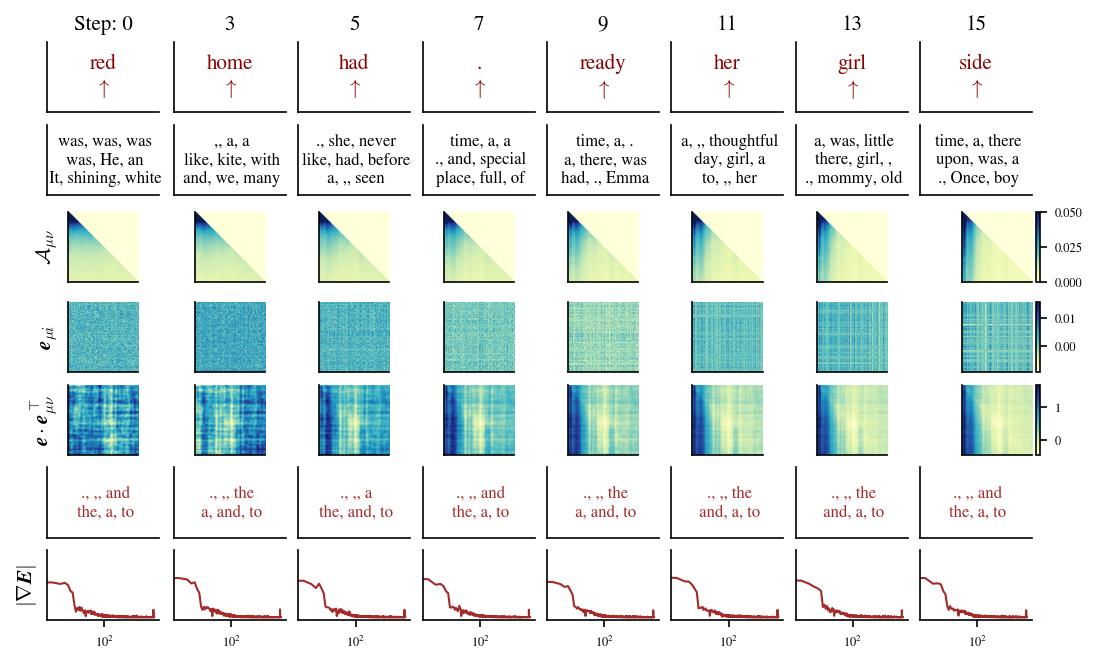

In [150]:
# Variables

step_matrix = summary_matrices['matrix_steps']
n = len(step_matrix)
h_ratios = [1,1,1,1,1,1,1]
top_attended_tokens = 9
top_grad_tokens = 6
# Create figure
fig , axes = create_fig(nrows=7,ncols=n,size='double',h=0.6,sharex=False,sharey=False,h_ratios=h_ratios)


for ax in axes.flatten():
    ax.set_xticks([])
    ax.set_yticks([])
#     ax.set_axis_off()

# Next token to predict
axs = axes[0]
for i , ax in enumerate(axs):
    # ax.set_axis_off()
    ax.set_title(f'Step: {step_matrix[i]}' if i==0 else f'{step_matrix[i]}')
    variable = summary_matrices['tokens_next'][i][i_seq_frac]  
    ax.text(0.5, 0.5, f'{variable}\n'+r'$\uparrow$', fontsize=FONTSIZES['m'], va='center', ha='center', transform=ax.transAxes,color='darkred')

# Token being attended to
axs = axes[1]
for i , ax in enumerate(axs):
    # ax.set_axis_off()
    variable = summary_matrices['tokens_attended'][i][i_seq_frac]  
    text = '\n'.join([f' {variable[j]}, {variable[j+1]}, {variable[j+2]}' for j in range(0,top_attended_tokens-2,3)]) 
    ax.text(0.5, 0.5, text, fontsize=FONTSIZES['s'], va='center', ha='center', transform=ax.transAxes)
    

# Attention Patterns
axs = axes[2]
axs[0].set_ylabel(r'$\mathcal{A}_{\mu \nu}$')
for i , ax in enumerate(axs):
    variable = summary_matrices['A'][i]  # (L, L)
    ax.imshow(variable,vmax=0.05,cmap='YlGnBu')
    
    if i == n-1:
        plt.colorbar(ax.images[0], ax=ax, fraction=0.046, pad=0.04)


axs = axes[3]
axs[0].set_ylabel(r'$\boldsymbol{e}_{\mu i}$')
for i , ax in enumerate(axs):
    e = summary_matrices['e'][i]  # (L, d)
    W = summary_matrices['W'][i]  # (d, d)
    variable = e @ W @ e.T / d  # (L, L)
    ax.imshow(variable,cmap='YlGnBu')
    if i == n-1:
        plt.colorbar(ax.images[0], ax=ax, fraction=0.046, pad=0.04)

# p W p^T
axs = axes[4]
axs[0].set_ylabel(r'$\boldsymbol{e} \cdot \boldsymbol{e}^\top_{\mu \nu}$')
for i , ax in enumerate(axs):
    p = summary_matrices['x'][i]  - summary_matrices['e'][i]  # (L, d)
    W = summary_matrices['W'][i]  # (d, d)
    variable = p @ W @ p.T / d  # (L, L)
    # variable =  auxiliar @ auxiliar.T/d  # (L, L)
    print(variable.min(), variable.max(),i)
    ax.imshow(variable,cmap='YlGnBu')#,vmin=-0.05,vmax=0.05)
    if i == n-1:
        plt.colorbar(ax.images[0], ax=ax, fraction=0.046, pad=0.04)

# Top embedding gradient tokens
axs = axes[5]
# axs[0].set_ylabel(r'Top Gradients')
for i , ax in enumerate(axs):
    variable = summary_matrices['embedd_grad_norms'][i]  # (vocab_size,)
    top_gradient_tokens = np.argsort(-variable)[:top_grad_tokens]
    tokens = [tokenizer.id_to_token(j) for j in top_gradient_tokens]
    text = '\n'.join([f' {tokens[j]}, {tokens[j+1]}, {tokens[j+2]}' for j in range(0,top_grad_tokens-2,3)]) 
    ax.text(0.5, 0.5, text, fontsize=FONTSIZES['s'], va='center', ha='center', transform=ax.transAxes,color='brown')
    

# Embedding Gradients
axs = axes[6]
axs[0].set_ylabel(r'$|\nabla \boldsymbol{E}|$')
for i , ax in enumerate(axs):
    ax.set_xscale('log')
    variable = summary_matrices['embedd_grad_norms'][i][sorted_tokens]  # (vocab_size,)
    ax.plot(variable,color='brown',lw=1.)

# fig.text(0., 0.54, r'$\Biggl\{$', fontsize=50, va='center', ha='center', transform=fig.transFigure)

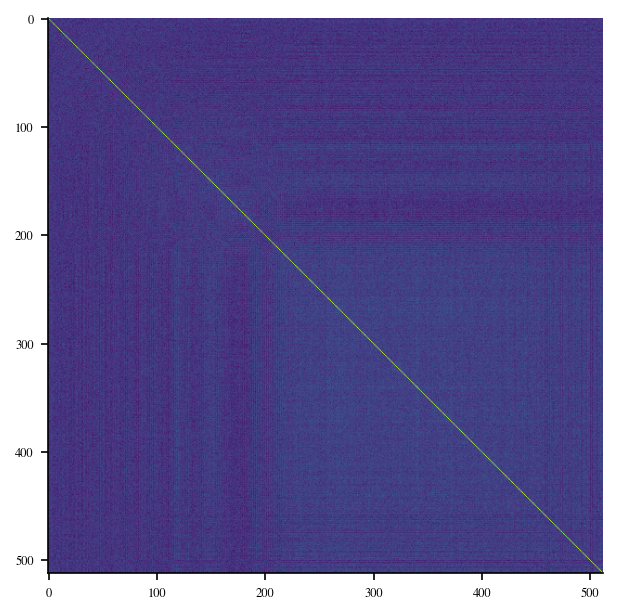

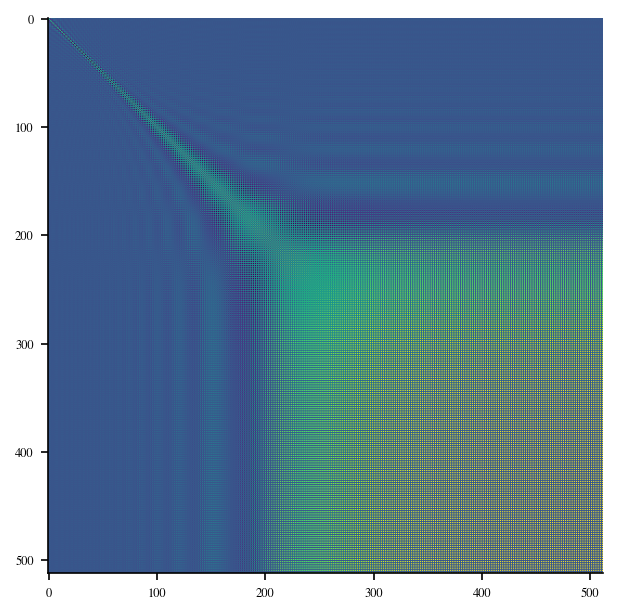

In [ ]:
plt.imshow(W@W.T)
plt.show()

plt.imshow(p.T@p)
plt.show()

M = np.array([[1,2,3],[4,5,6],[7,8,9],[10,11,12]])
print(M.shape)
print(M)
plt.imshow(M)
plt.colorbar()
plt.show()

(4, 3)
[[ 1  2  3]
 [ 4  5  6]
 [ 7  8  9]
 [10 11 12]]


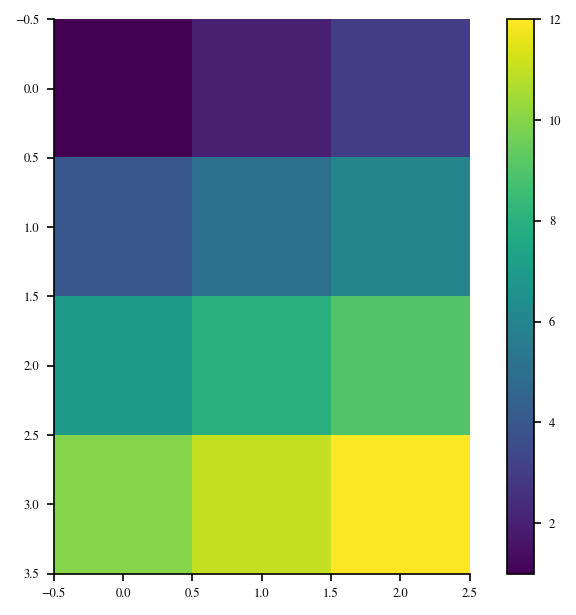

In [72]:
M = np.array([[1,2,3],[4,5,6],[7,8,9],[10,11,12]])
print(M.shape)
print(M)
plt.imshow(M)
plt.colorbar()